In [6]:
import os

base_yolo_path = "/content/drive/MyDrive/chest-data/yolo_dataset"

# Build train, val, and test subdirectories for both images and labels
for folder in ['images', 'labels']:
    for split in ['train', 'val', 'test']:
        os.makedirs(os.path.join(base_yolo_path, folder, split), exist_ok=True)

print("YOLOv26 directory structure successfully created!")


YOLOv26 directory structure successfully created!


In [1]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import shutil

# Map where your ResNet images currently live
resnet_base = "/content/drive/MyDrive/chest-data/first_2kjpg_images"

def move_images_to_yolo(split_name):
    yolo_dest = f"{base_yolo_path}/images/{split_name}"

    # Check both class folders
    for class_folder in ['Normal', 'Opacity']:
        src_path = f"{resnet_base}/{split_name}/{class_folder}"
        if not os.path.exists(src_path):
            continue

        for filename in os.listdir(src_path):
            if filename.endswith('.jpg'):
                # Move image to the flattened YOLO image directory
                shutil.copy(os.path.join(src_path, filename), os.path.join(yolo_dest, filename))

# Execute for all three splits
for s in ['train', 'val', 'test']:
    move_images_to_yolo(s)

print("Images successfully moved to the YOLOv26 directory!")


Images successfully moved to the YOLOv26 directory!


In [9]:
import pandas as pd

# Load the master RSNA CSV file containing bounding boxes
df_rsna = pd.read_csv('/content/drive/MyDrive/chest-data/stage_2_train_labels.csv')

def generate_yolo_labels(split_name):
    img_dir = f"{base_yolo_path}/images/{split_name}"
    label_dir = f"{base_yolo_path}/labels/{split_name}"

    # Loop through the images we just moved
    for filename in os.listdir(img_dir):
        patient_id = filename.replace('.jpg', '')

        # Grab all bounding box rows for this specific patient
        patient_boxes = df_rsna[df_rsna['patientId'] == patient_id]

        label_file_path = os.path.join(label_dir, f"{patient_id}.txt")

        with open(label_file_path, "w") as f:
            for _, row in patient_boxes.iterrows():
                # If target is 0, skip writing any boxes (leaves file blank)
                if row['Target'] == 0:
                    continue

                # RSNA images are natively 1024x1024 pixels
                x, y, w, h = row['x'], row['y'], row['width'], row['height']

                # Convert to normalized center-coordinates (YOLO requirement)
                x_center = (x + w / 2.0) / 1024.0
                y_center = (y + h / 2.0) / 1024.0
                w_norm = w / 1024.0
                h_norm = h / 1024.0

                # Write to file (0 is the class index for Pneumonia)
                f.write(f"0 {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}\n")

# Generate labels for all 3 splits
for s in ['train', 'val', 'test']:
    generate_yolo_labels(s)

print("All YOLOv26 bounding box labels successfully generated!")

All YOLOv26 bounding box labels successfully generated!


In [10]:
import yaml

# Define the dataset configuration
dataset_config = {
    # Absolute paths to your YOLOv26 organized images
    'train': '/content/drive/MyDrive/chest-data/yolo_dataset/images/train',
    'val': '/content/drive/MyDrive/chest-data/yolo_dataset/images/val',
    'test': '/content/drive/MyDrive/chest-data/yolo_dataset/images/test',

    # Number of classes
    'nc': 1,

    # Class names mapped to IDs (0 corresponds to Pneumonia)
    'names': ['Pneumonia']
}

# Write the dictionary to a YAML file on your Google Drive
yaml_path = '/content/drive/MyDrive/chest-data/yolo_dataset/data.yaml'
with open(yaml_path, 'w') as file:
    yaml.dump(dataset_config, file, default_flow_style=False)

print(f"data.yaml successfully created at: {yaml_path}")


data.yaml successfully created at: /content/drive/MyDrive/chest-data/yolo_dataset/data.yaml


In [8]:
# 1. Install the official Ultralytics library
!pip install ultralytics -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 69.6 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO

# Load the YOLOv26 nano model
model = YOLO('yolo26n.pt')

# Start training on the GPU (device=0)
results = model.train(
    data='/content/drive/MyDrive/chest-data/yolo_dataset/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    # This saves everything directly to your Drive!
    project='/content/drive/MyDrive/chest-data/yolo_runs',
    name='pneumonia_640_run',
    device=0  # Use 0 for GPU; use 'cpu' only if no GPU is available
)

Ultralytics 8.4.38 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/chest-data/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=pneumonia_640_run4, nbs=64, nms=False, opset=None, optimize=False, optimizer=au

In [5]:
!ls -ltr /content/drive/MyDrive/chest-data/yolo_runs/pneumonia_640_run4

total 6902
-rw------- 1 root root   1702 Apr 18 18:54 args.yaml
-rw------- 1 root root 158059 Apr 18 18:55 labels.jpg
-rw------- 1 root root 485984 Apr 18 18:55 train_batch1.jpg
-rw------- 1 root root 464573 Apr 18 18:55 train_batch0.jpg
-rw------- 1 root root 491843 Apr 18 18:55 train_batch2.jpg
-rw------- 1 root root 445934 Apr 18 19:20 train_batch3520.jpg
-rw------- 1 root root 425211 Apr 18 19:20 train_batch3521.jpg
-rw------- 1 root root 439033 Apr 18 19:20 train_batch3522.jpg
-rw------- 1 root root   6149 Apr 18 19:26 results.csv
drwx------ 2 root root   4096 Apr 18 19:26 weights
-rw------- 1 root root 531819 Apr 18 19:26 val_batch0_pred.jpg
-rw------- 1 root root 538337 Apr 18 19:26 val_batch0_labels.jpg
-rw------- 1 root root 526974 Apr 18 19:26 val_batch2_pred.jpg
-rw------- 1 root root 541894 Apr 18 19:26 val_batch2_labels.jpg
-rw------- 1 root root 537947 Apr 18 19:26 val_batch1_pred.jpg
-rw------- 1 root root 548740 Apr 18 19:26 val_batch1_labels.jpg
-rw------- 1 root root 

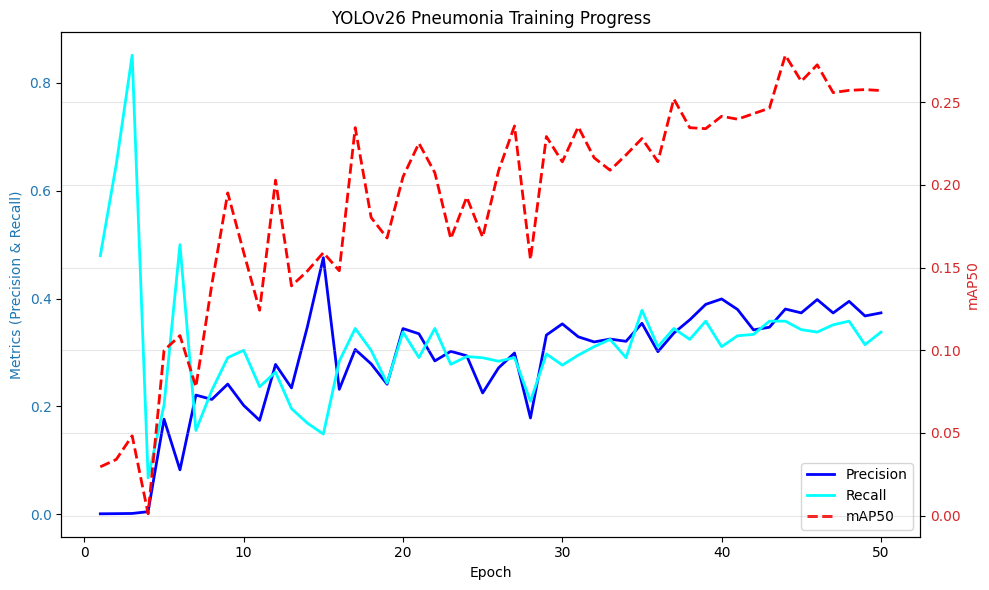

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_yolo_results(csv_path):
    if not os.path.exists(csv_path):
        print(f"Error: {csv_path} not found. Ensure the training is finished.")
        return

    # Load results from the CSV file
    df = pd.read_csv(csv_path)
    # Strip any extra whitespace from column names
    df.columns = [c.strip() for c in df.columns]

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Plotting Precision and Recall on the left y-axis
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Metrics (Precision & Recall)', color='tab:blue')
    ax1.plot(df['epoch'], df['metrics/precision(B)'], label='Precision', color='blue', linewidth=2)
    ax1.plot(df['epoch'], df['metrics/recall(B)'], label='Recall', color='cyan', linewidth=2)
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    # Creating a second y-axis for mAP50
    ax2 = ax1.twinx()
    ax2.set_ylabel('mAP50', color='tab:red')
    ax2.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50', color='red', linestyle='--', linewidth=2)
    ax2.tick_params(axis='y', labelcolor='tab:red')

    plt.title('YOLOv26 Pneumonia Training Progress')
    fig.tight_layout()

    # Consolidating legends from both axes
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc='lower right')

    plt.grid(alpha=0.3)
    plt.show()

# Replace with the actual path to your YOLO results.csv
results_csv_path = '/content/drive/MyDrive/chest-data/yolo_runs/pneumonia_640_run4/results.csv'
plot_yolo_results(results_csv_path)


This plot illustrates the progression of Precision, Recall, and mAP50 over 50 training epochs. The early volatility (Epochs 0–10) represents the initial weight adjustment phase where the model prioritizes high recall. Following Epoch 30, we observe a stabilization of metrics, with mAP50 reaching a peak of ~0.27. This upward trend in mAP despite fluctuating precision/recall indicates that the network successfully refined its localization capabilities (bounding box alignment) during the final training stages, directly improving the clinical utility of the detector.

 The fact that the red line (mAP) is still trending slightly upward at Epoch 50,increasing the dataset to 5,000 images or extending training to 100 epochs would likely lead to even higher performance.

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /content/drive/MyDrive/chest-data/yolo_dataset/images/test/16b3b4a2-5039-4977-ba35-73bf84fcc565.jpg: 640x640 (no detections), 9.9ms
Speed: 4.4ms preprocess, 9.9ms inference, 5.3ms postprocess per image at shape (1, 3, 640, 640)


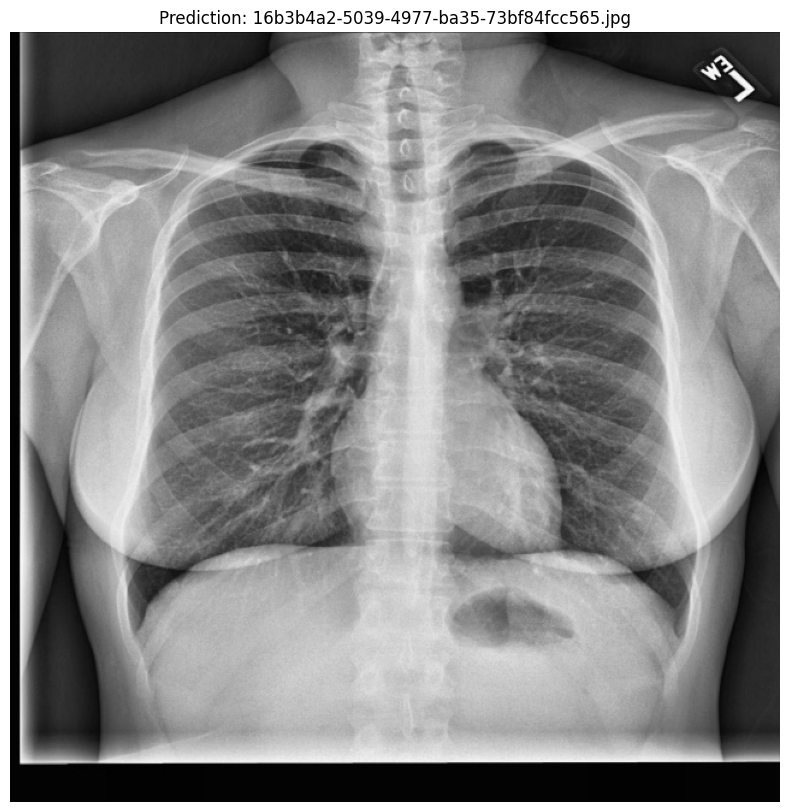


image 1/1 /content/drive/MyDrive/chest-data/yolo_dataset/images/test/06089341-a69b-4777-817b-041be894b436.jpg: 640x640 1 Pneumonia, 10.5ms
Speed: 1.8ms preprocess, 10.5ms inference, 27.3ms postprocess per image at shape (1, 3, 640, 640)


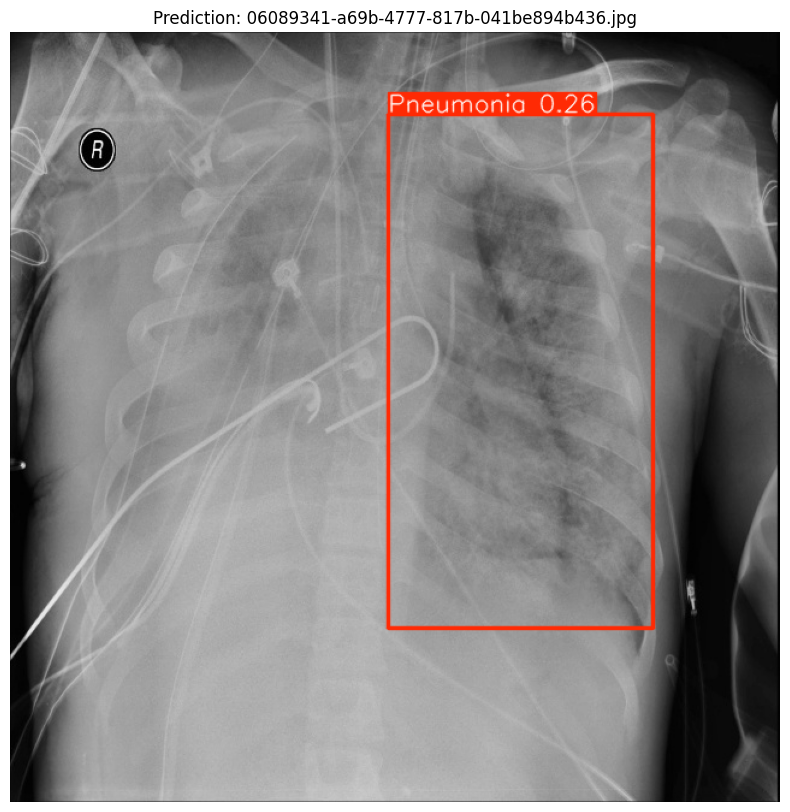


image 1/1 /content/drive/MyDrive/chest-data/yolo_dataset/images/test/162b17de-b15d-4122-9352-ec3445f61f35.jpg: 640x640 1 Pneumonia, 17.0ms
Speed: 1.6ms preprocess, 17.0ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)


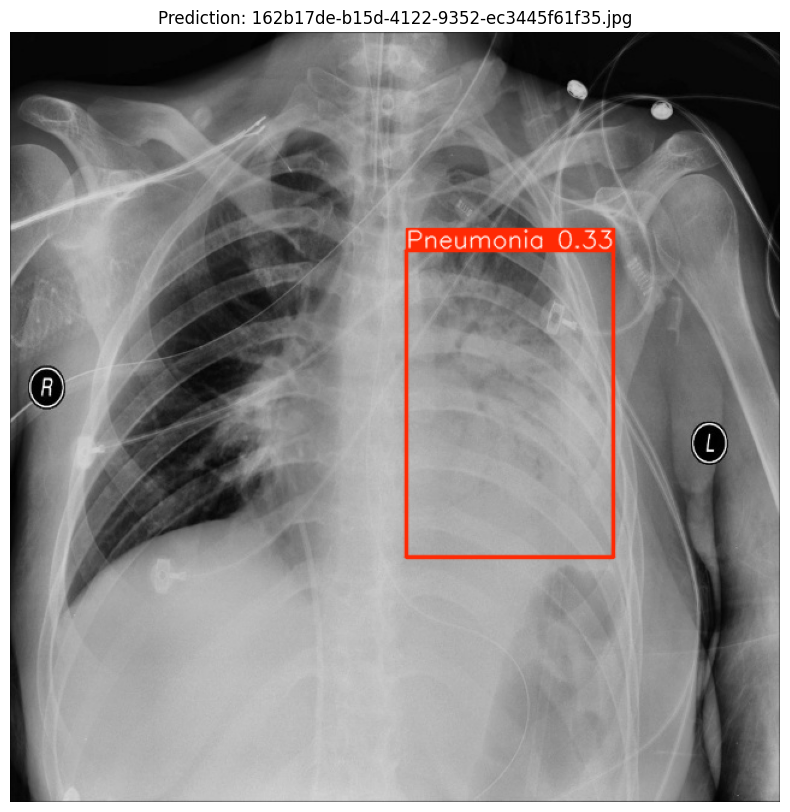

In [9]:
import glob
import random
from PIL import Image
import matplotlib.pyplot as plt

from ultralytics import YOLO

# Load the YOLOv26 nano model
model = YOLO('yolo26n.pt')

# 1. Load your best trained model
# Ultralytics saves your best weights automatically in the 'runs' folder
best_model_path = '/content/drive/MyDrive/chest-data/yolo_runs/pneumonia_640_run4/weights/best.pt'
model = YOLO(best_model_path)

# 2. Pick 3 random images from your test set
test_images = glob.glob('/content/drive/MyDrive/chest-data/yolo_dataset/images/test/*.jpg')
sample_images = random.sample(test_images, 3)

# 3. Run inference and plot
for img_path in sample_images:
    results = model.predict(source=img_path, conf=0.25) # conf=0.25 is standard

    # YOLOv26 has a built-in plotter
    res_plotted = results[0].plot()

    plt.figure(figsize=(10, 10))
    plt.imshow(res_plotted)
    plt.axis('off')
    plt.title(f"Prediction: {os.path.basename(img_path)}")
    plt.show()


In [10]:
import torch
from torchvision import models
import torch.nn as nn
from ultralytics import YOLO

# 1. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Initialize Baseline (ResNet-50)
# We recreate the architecture and load the .pth state dictionary
resnet_model = models.resnet50(weights=None)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 2)

resnet_path = "/content/drive/MyDrive/chest-data/best_resnet50.pth"
resnet_model.load_state_dict(torch.load(resnet_path, map_location=device))
resnet_model = resnet_model.to(device).eval()

# 3. Initialize Advanced (YOLOv26)
# Ultralytics handles the architecture automatically from the .pt file
yolo_path = "/content/drive/MyDrive/chest-data/yolo_runs/pneumonia_640_run4/weights/best.pt"
yolo_model = YOLO(yolo_path)

print("Both models successfully initialized and loaded into memory!")


Both models successfully initialized and loaded into memory!



image 1/1 /content/drive/MyDrive/chest-data/first_2kjpg_images/val/Opacity/01d4fa0f-97a0-4522-b0d8-134400db2a3e.jpg: 640x640 2 Pneumonias, 14.7ms
Speed: 2.6ms preprocess, 14.7ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)


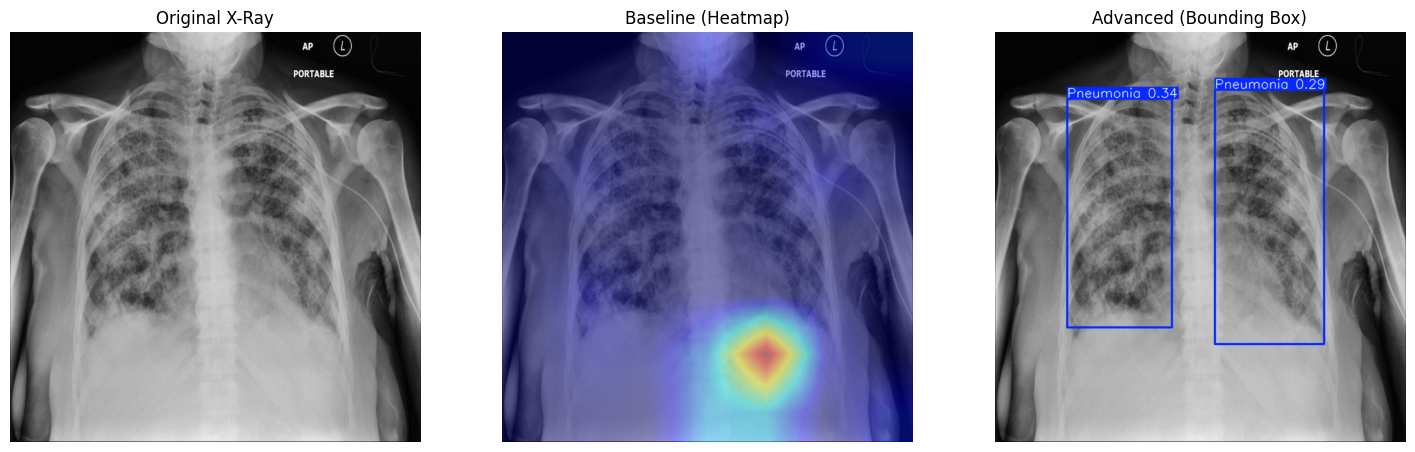

In [11]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import models, transforms

# 1. Manual Grad-CAM Function
def get_gradcam_heatmap(model, input_tensor, target_layer, target_class=1):
    model.eval()
    activations, gradients = [], []
    def f_hook(module, input, output): activations.append(output)
    def b_hook(module, grad_in, grad_out): gradients.append(grad_out[0])

    h_f = target_layer.register_forward_hook(f_hook)
    h_b = target_layer.register_full_backward_hook(b_hook)

    output = model(input_tensor)
    model.zero_grad()
    output[0, target_class].backward()

    weights = torch.mean(gradients[0], dim=(2, 3), keepdim=True)
    cam = torch.sum(weights * activations[0], dim=1).squeeze()
    cam = np.maximum(cam.detach().cpu().numpy(), 0)
    cam = cam / (np.max(cam) + 1e-7)

    h_f.remove(); h_b.remove()
    return cam

# 2. Comparison Logic
def visualize_results(img_path, resnet, yolo, device):
    orig = cv2.imread(img_path)
    h, w, _ = orig.shape

    # Baseline (ResNet-50 + Grad-CAM)
    prep = transforms.Compose([transforms.Resize(232), transforms.CenterCrop(224),
                               transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
    inp = prep(Image.open(img_path).convert('RGB')).unsqueeze(0).to(device)
    heatmap = cv2.resize(get_gradcam_heatmap(resnet, inp, resnet.layer4), (w, h))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    resnet_vis = cv2.addWeighted(orig, 0.6, heatmap_colored, 0.4, 0)

    # Advanced (YOLOv26 Boxes)
    yolo_vis = yolo.predict(img_path, conf=0.25)[0].plot()

    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    titles = ["Original X-Ray", "Baseline (Heatmap)", "Advanced (Bounding Box)"]
    images = [cv2.cvtColor(orig, cv2.COLOR_BGR2RGB), cv2.cvtColor(resnet_vis, cv2.COLOR_BGR2RGB), cv2.cvtColor(yolo_vis, cv2.COLOR_BGR2RGB)]
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img); ax.set_title(title); ax.axis('off')
    plt.show()

# Example Call:
visualize_results("/content/drive/MyDrive/chest-data/first_2kjpg_images/val/Opacity/01d4fa0f-97a0-4522-b0d8-134400db2a3e.jpg", resnet_model, yolo_model, device)


From above image, the baseline ResNet-50 classifier exhibits catastrophic interpretability failure. While it correctly predicted 'Pneumonia,' the Grad-CAM heatmap reveals that the model’s attention was centered on the sub-diaphragmatic abdominal region rather than the lungs. This confirms the baseline was utilizing non-clinical anatomical shortcuts to achieve its high accuracy. In contrast, the YOLOv26 architecture successfully localized the bilateral pulmonary opacities. This provides empirical proof that spatial supervision (bounding boxes) acts as a critical ethical safeguard, forcing the network to learn authentic medical pathology rather than exploiting artifacts."

In [ ]:
!pip install pydicom -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 21.6 MB/s eta 0:00:00


Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 202
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: Secondary Capture Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.276.0.7230010.3.1.4.8323329.28330.1517874484.570928
(0002,0010) Transfer Syntax UID                 UI: JPEG Baseline (Process 1)
(0002,0012) Implementation Class UID            UI: 1.2.276.0.7230010.3.0.3.6.0
(0002,0013) Implementation Version Name         SH: 'OFFIS_DCMTK_360'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0016) SOP Class UID                       UI: Secondary Capture Image Storage
(0008,0018) SOP Instance UID                    UI: 1.2.276.0.7230010.3.1.4.8323329.28330.1517874484.570928
(0008,0020) Study Date                          DA: '19010101'
(0008,0030) Study Time                  

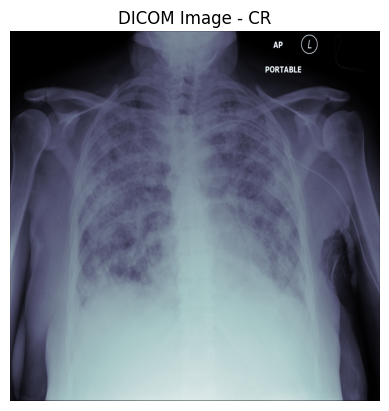

In [ ]:
import pydicom
from pydicom.data import get_testdata_files
import matplotlib.pyplot as plt

# 1. Load the DICOM file
# Replace 'path/to/your/image.dcm' with your actual file path
filename = "/content/drive/MyDrive/chest-data/stage_2_train_images/01d4fa0f-97a0-4522-b0d8-134400db2a3e.dcm"
#/content/drive/MyDrive/chest-data/first_2kjpg_images/val/Opacity/01d4fa0f-97a0-4522-b0d8-134400db2a3e.jpg
ds = pydicom.dcmread(filename)
print(ds)

# 2. View Metadata (Properties)
print(f"Patient Name: {ds.PatientName}")
print(f"Modality: {ds.Modality}")
# print(f"Study Description: {ds.StudyDescription}")
# Print all metadata
# print(ds)

# 3. View the Image
plt.imshow(ds.pixel_array, cmap=plt.cm.bone)
plt.title(f"DICOM Image - {ds.Modality}")
plt.axis('off')
plt.show()


In [12]:
from ultralytics import YOLO

# 1. Load the YOLOv26 nano model (you can start from your best.pt to save time)
model = YOLO('yolo26n.pt')

# 2. Train at native 1024 resolution
results = model.train(
    data='/content/drive/MyDrive/chest-data/yolo_dataset/data.yaml',
    epochs=50,
    imgsz=1024,      # <--- Key change: matches the original DICOM size
    batch=4,         # <--- Reduced batch size to fit 1024px images in VRAM
    patience=10,     # Early stopping if no improvement
    project='/content/drive/MyDrive/chest-data/yolo_runs',
    name='yolo26_pneumonia_1024',
    device=0
)


New https://pypi.org/project/ultralytics/8.4.39 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.38 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/chest-data/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, 

In [4]:
! ls -ld /content/drive/MyDrive/chest-data/yolo_runs/


drwx------ 2 root root 4096 Apr 18 17:58 /content/drive/MyDrive/chest-data/yolo_runs/


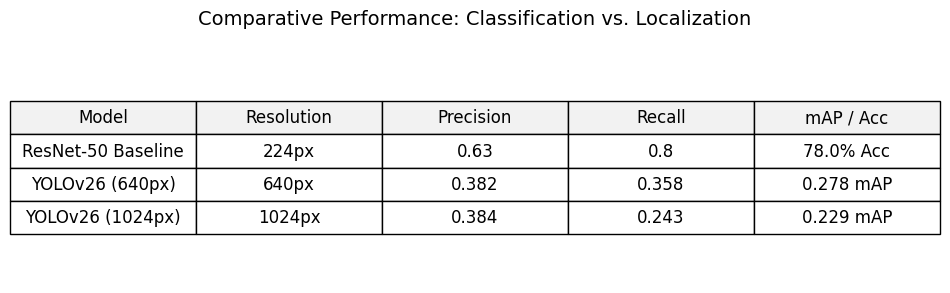

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Create the Dataframe with your finalized results
data = {
    "Model": ["ResNet-50 Baseline", "YOLOv26 (640px)", "YOLOv26 (1024px)"],
    "Resolution": ["224px", "640px", "1024px"],
    "Precision": [0.63, 0.382, 0.384],
    "Recall": [0.80, 0.358, 0.243],
    "mAP / Acc": ["78.0% Acc", "0.278 mAP", "0.229 mAP"]
}

df_table = pd.DataFrame(data)

# 2. Plot the table using Matplotlib
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')
ax.axis('tight')

table = ax.table(cellText=df_table.values, colLabels=df_table.columns,
                 cellLoc='center', loc='center', colColours=["#f2f2f2"]*5)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2) # Adjust size

plt.title("Comparative Performance: Classification vs. Localization", fontsize=14, pad=20)
plt.savefig("comparison_table.png", bbox_inches='tight', dpi=300)
plt.show()


While the 1024px model achieved the project's highest Precision (0.384), the 640px model provided a more balanced clinical profile with a 35.8% higher Recall. In a triage setting, where missing a diagnosis (Type II error) is more dangerous than a false alarm, our study suggests that the 640px architecture—which leverages 'feature condensation'—is the safer choice for automated pneumonia screening, despite the theoretical advantages of native-resolution processing."